In [1]:
import rasterio
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

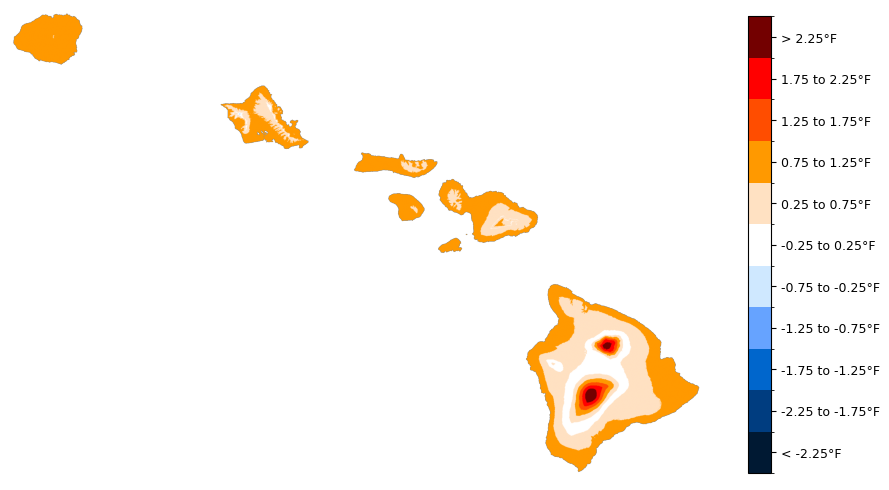

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Clean °F anomaly thresholds (ΔF). Data is still °C anomalies.
# 5 cold bins + neutral + 5 warm bins
thresholds_f = [
    (-np.inf, -2.25, "#001933", "< -2.25°F"),
    (-2.25,   -1.75, "#003d80", "-2.25 to -1.75°F"),
    (-1.75,   -1.25, "#0066CC", "-1.75 to -1.25°F"),
    (-1.25,   -0.75, "#66a3ff", "-1.25 to -0.75°F"),
    (-0.75,   -0.25, "#cfe8ff", "-0.75 to -0.25°F"),
    (-0.25,    0.25, "#FFFFFF", "-0.25 to 0.25°F"),
    ( 0.25,    0.75, "#ffe1c2", "0.25 to 0.75°F"),
    ( 0.75,    1.25, "#FF9900", "0.75 to 1.25°F"),
    ( 1.25,    1.75, "#FF4d00", "1.25 to 1.75°F"),
    ( 1.75,   2.25, "#FF0000", "1.75 to 2.25°F"),
    ( 2.25,  np.inf, "#730000", "> 2.25°F"),
]

# Convert °F anomaly edges to °C anomaly edges for classification (ΔC = ΔF / 1.8)
def f_to_c_anom(x):
    if np.isneginf(x) or np.isposinf(x):
        return x
    return x / 1.8

# Build classification thresholds in °C, but keep °F labels/colors
thresholds = [(f_to_c_anom(lo), f_to_c_anom(hi), color, label)
              for lo, hi, color, label in thresholds_f]

with rasterio.open("annual_tmean_2025_anomaly.tif") as src:
    data = src.read(1).astype("float32")
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)

categorical = np.full_like(data, 255, dtype=np.uint8)

# classify using °C edges derived from clean °F edges
for i, (low_c, high_c, _, _) in enumerate(thresholds):
    mask = (data > low_c) & (data <= high_c)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress="lzw", nodata=255)

# Plot with °F legend
colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('../../public/climate-summary/annual_tmean_2025_anomaly.png', dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()


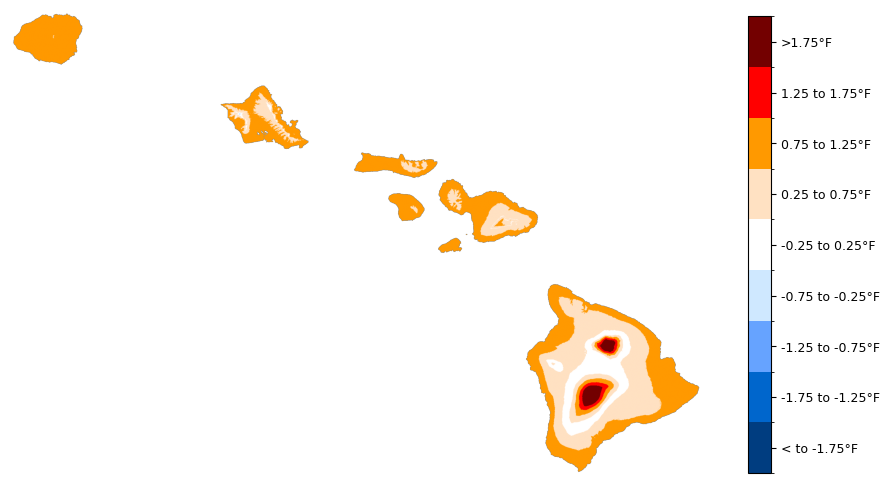

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Clean °F anomaly thresholds (ΔF). Data is still °C anomalies.
# 5 cold bins + neutral + 5 warm bins
thresholds_f = [
    (-np.inf,   -1.75, "#003d80", "< to -1.75°F"),
    (-1.75,   -1.25, "#0066CC", "-1.75 to -1.25°F"),
    (-1.25,   -0.75, "#66a3ff", "-1.25 to -0.75°F"),
    (-0.75,   -0.25, "#cfe8ff", "-0.75 to -0.25°F"),
    (-0.25,    0.25, "#FFFFFF", "-0.25 to 0.25°F"),
    ( 0.25,    0.75, "#ffe1c2", "0.25 to 0.75°F"),
    ( 0.75,    1.25, "#FF9900", "0.75 to 1.25°F"),
    ( 1.25,    1.75, "#FF0000", "1.25 to 1.75°F"),
    ( 1.75,   np.inf, "#730000", ">1.75°F"),
]

# thresholds_f = [
#     (-np.inf, -2.25, "#001933", "< -2.25°F"),
#     (-2.25,   -1.75, "#003d80", "-2.25 to -1.75°F"),
#     (-1.75,   -1.25, "#0066CC", "-1.75 to -1.25°F"),
#     (-1.25,   -0.75, "#66a3ff", "-1.25 to -0.75°F"),
#     (-0.75,   -0.25, "#cfe8ff", "-0.75 to -0.25°F"),
#     (-0.25,    0.25, "#FFFFFF", "-0.25 to 0.25°F"),
#     ( 0.25,    0.75, "#ffe1c2", "0.25 to 0.75°F"),
#     ( 0.75,    1.25, "#FF9900", "0.75 to 1.25°F"),
#     ( 1.25,    1.75, "#FF4d00", "1.25 to 1.75°F"),
#     ( 1.75,   2.25, "#FF0000", "1.75 to 2.25°F"),
#     ( 2.25,  np.inf, "#730000", "> 2.25°F"),
# ]

# Convert °F anomaly edges to °C anomaly edges for classification (ΔC = ΔF / 1.8)
def f_to_c_anom(x):
    if np.isneginf(x) or np.isposinf(x):
        return x
    return x / 1.8

# Build classification thresholds in °C, but keep °F labels/colors
thresholds = [(f_to_c_anom(lo), f_to_c_anom(hi), color, label)
              for lo, hi, color, label in thresholds_f]

with rasterio.open("annual_tmean_2025_anomaly.tif") as src:
    data = src.read(1).astype("float32")
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)

categorical = np.full_like(data, 255, dtype=np.uint8)

# classify using °C edges derived from clean °F edges
for i, (low_c, high_c, _, _) in enumerate(thresholds):
    mask = (data > low_c) & (data <= high_c)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress="lzw", nodata=255)

# Plot with °F legend
colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('../../public/climate-summary/annual_tmean_2025_anomaly.png', dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()
